# Bank Fraud Detection - ML Model

**Problem:** Banks lose billions annually to fraudulent transactions. Fraud analysts need an automated system to flag suspicious transactions instantly.

**Dataset:** Kaggle Credit Card Fraud Detection (creditcard.csv)
- 284,807 transactions
- Features V1-V28 (PCA transformed), Time, Amount
- Class: 0 = Legitimate, 1 = Fraud

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

print(' Libraries loaded successfully!')

 Libraries loaded successfully!


## Step 2: Load & Explore the Data

In [2]:
df = pd.read_csv('creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print('=== Dataset Info ===')
print(f'Total Transactions : {len(df):,}')
print(f'Legitimate (0)     : {df["Class"].value_counts()[0]:,}')
print(f'Fraudulent (1)     : {df["Class"].value_counts()[1]:,}')
print(f'Fraud %            : {df["Class"].mean()*100:.4f}%')
print(f'Missing Values     : {df.isnull().sum().sum()}')

=== Dataset Info ===
Total Transactions : 284,807
Legitimate (0)     : 284,315
Fraudulent (1)     : 492
Fraud %            : 0.1727%
Missing Values     : 0


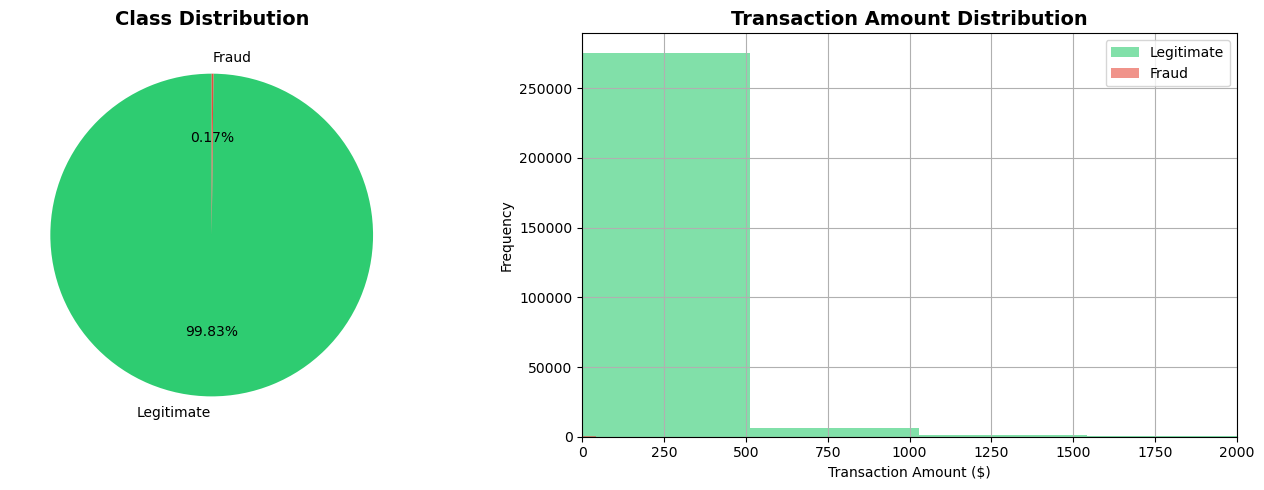

 EDA plots saved!


In [4]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['Class'].value_counts()
axes[0].pie(counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Amount distribution by class
df[df['Class']==0]['Amount'].hist(ax=axes[1], bins=50, alpha=0.6, color='#2ecc71', label='Legitimate')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, alpha=0.6, color='#e74c3c', label='Fraud')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA plots saved!')

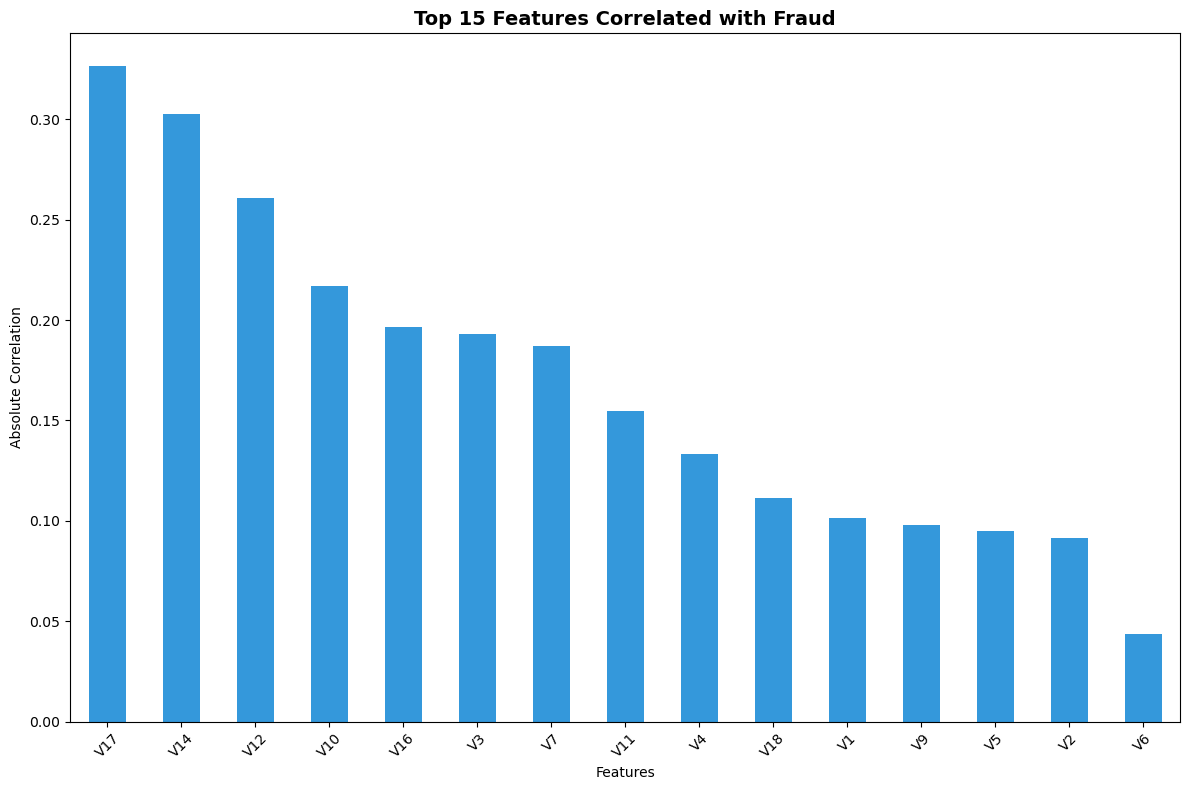

In [5]:
# Correlation heatmap (top features)
plt.figure(figsize=(12, 8))
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(15)
corr.plot(kind='bar', color='#3498db')
plt.title('Top 15 Features Correlated with Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('correlation_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Preprocessing & Feature Engineering

In [6]:
# Scale Amount and Time (V1-V28 are already PCA scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Features and target
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')

Train size: (227845, 30)
Test size : (56962, 30)


In [7]:
# Handle class imbalance with SMOTE
print('Before SMOTE:', y_train.value_counts().to_dict())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print('After SMOTE :', pd.Series(y_train_bal).value_counts().to_dict())
print('Class imbalance handled with SMOTE!')

Before SMOTE: {0: 227451, 1: 394}
After SMOTE : {0: 227451, 1: 227451}
Class imbalance handled with SMOTE!


## Step 4: Train Models & Compare

In [9]:
# Train Random Forest
print(' Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print(f'Random Forest ROC-AUC: {rf_auc:.4f}')

# Train Logistic Regression
print('\n📈 Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bal, y_train_bal)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')

 Training Random Forest...
Random Forest ROC-AUC: 0.9688

📈 Training Logistic Regression...
Logistic Regression ROC-AUC: 0.9698


In [ ]:
# Pick the best model
best_model = rf_model if rf_auc >= lr_auc else lr_model
best_preds = rf_preds if rf_auc >= lr_auc else lr_preds
best_proba = rf_proba if rf_auc >= lr_auc else lr_proba
best_name = 'Random Forest' if rf_auc >= lr_auc else 'Logistic Regression'
print(f' Best Model: {best_name}')
print('\n=== Classification Report ===')
print(classification_report(y_test, best_preds, target_names=['Legitimate', 'Fraud']))

In [ ]:
# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix - {best_name}', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc_score(y_test, best_proba):.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Model performance plots saved!')

## Step 5: Save Model & Scaler

In [ ]:
# Save model and scaler for Streamlit app
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('features.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print(' model.pkl saved!')
print(' scaler.pkl saved!')
print(' features.pkl saved!')


In [ ]:
!streamlit run app-2.py